<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/TrabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sistema de Análise de Crédito  
Nomes: Kauã de Oliveira Ribeiro, João Gabriel F. Ribeiro

In [22]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import seaborn as sns
!pip install category_encoders
from category_encoders import TargetEncoder
from scipy.stats import mstats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
)

# **Etapa 1: Base de Dados**

In [ ]:
# Importa os arquivos csv com os dados dos clientes
app_df = pd.read_csv("/application_record.csv")
credit_df = pd.read_csv("/credit_record.csv")

# Exibe as bases de dados que serão utilizadas no projeto extraídas do link abaixo
# https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction
display(app_df)
print()
display(credit_df)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [ ]:
# Renomeando as colunas da tabela de application_record
app_df.rename(columns={
    'CODE_GENDER': 'Genero',
    'FLAG_OWN_CAR': 'Tem_Carro',
    'FLAG_OWN_REALTY': 'Tem_Imovel',
    'CNT_CHILDREN': 'Qtd_Filhos',
    'AMT_INCOME_TOTAL': 'Renda_Anual',
    'NAME_INCOME_TYPE': 'Tipo_Renda',
    'NAME_EDUCATION_TYPE': 'Escolaridade',
    'NAME_FAMILY_STATUS': 'Estado_Civil',
    'NAME_HOUSING_TYPE': 'Tipo_Moradia',
    'DAYS_BIRTH': 'Idade',
    'DAYS_EMPLOYED': 'Anos_Empregado',
    'FLAG_MOBIL': 'Tem_Celular',
    'FLAG_WORK_PHONE': 'Tem_Tel_Trabalho',
    'FLAG_PHONE': 'Tem_Tel_Fixo',
    'FLAG_EMAIL': 'Tem_Email',
    'OCCUPATION_TYPE': 'Profissao',
    'CNT_FAM_MEMBERS': 'Tamanho_Familia'
}, inplace=True)

# Convertendo as colunas de idade e anos empregado de dias negativos para anos
app_df['Idade'] = np.abs(round(app_df['Idade'] / 365.25))
app_df['Anos_Empregado'] = np.where(
    app_df['Anos_Empregado'] > 0, 0,
    np.abs(round(app_df['Anos_Empregado'] / 365.25))
)

# Trocando os valores de 'Y' e 'N' por 'S' e 'N'
app_df['Tem_Carro']  = app_df['Tem_Carro'].map({'Y': 'S', 'N': 'N'})
app_df['Tem_Imovel'] = app_df['Tem_Imovel'].map({'Y': 'S', 'N': 'N'})

# Renomeando as colunas da tabela de credit_record
credit_df.rename(columns={
    'MONTHS_BALANCE': 'Meses_no_Banco',
    'STATUS': 'Status_Pagamento'
}, inplace=True)

status_map = {
    'C': 'Pago (Em dia)',
    'X': 'Sem empréstimo',
    '0': 'Atraso leve (1-29 dias)',
    '1': 'Atraso médio (30-59 dias)',
    '2': 'Atraso grave (60-89 dias)',
    '3': 'Atraso grave (90-119 dias)',
    '4': 'Atraso grave (120-149 dias)',
    '5': 'Dívida (>150 dias)'
}
credit_df['Status_Descricao'] = credit_df['Status_Pagamento'].map(status_map)

In [ ]:
MESES_AVALIACAO = 12  # Janela de avaliação de risco -> Consideramos o número de meses ao lado como a janela avaliada pelo banco na ánalise de crédito

# Analisando a tabela credit_record com base no intervalo de análise definido anteriormente
historico_passado   = credit_df[credit_df['Meses_no_Banco'] < -MESES_AVALIACAO]
periodo_avaliacao   = credit_df[credit_df['Meses_no_Banco'] >= -MESES_AVALIACAO]

# Criando a coluna alvo que utilizaremos nos modelos criados (Mau Pagador = Atraso grave no período avaliado)
periodo_avaliacao = periodo_avaliacao.copy()
periodo_avaliacao['Mau_Pagador'] = periodo_avaliacao['Status_Pagamento'].isin(
    ['2', '3', '4', '5']
)
target_df = periodo_avaliacao.groupby('ID')['Mau_Pagador'].max().reset_index()

# Criando as colunas de features dos clientes com base nos históricos deles
historico_features = historico_passado.groupby('ID').agg(
    Qtd_Meses_Historico        = ('Status_Pagamento', 'count'),
    Qtd_Atrasos_Leves          = ('Status_Pagamento', lambda x: x.isin(['0', '1']).sum()),
    Qtd_Atrasos_Graves         = ('Status_Pagamento', lambda x: x.isin(['2', '3', '4', '5']).sum()),
    Qtd_Meses_Pagos            = ('Status_Pagamento', lambda x: (x == 'C').sum()),
    Qtd_Meses_Sem_Emprestimo   = ('Status_Pagamento', lambda x: (x == 'X').sum()),
).reset_index()

historico_features['Percentual_Atrasos_Graves'] = (
    historico_features['Qtd_Atrasos_Graves'] / historico_features['Qtd_Meses_Historico']
)

In [ ]:
# Unindo as tabelas em um único dataframe para facilitar a utilização dos modelos criados
df = app_df.merge(target_df, on='ID', how='inner')
df = df.merge(historico_features, on='ID', how='left')

# Preenchendo os valores faltantes caso existam
df['Profissao'] = df['Profissao'].fillna('Nao Informado')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Convertendo a coluna alvo para inteiro
df['Mau_Pagador'] = df['Mau_Pagador'].astype(int)

# Winsorização do dataframe
# Trata os outliers extremos da base de dados (1% Mais ricos) antes do split
# Evita que esses valores mais absurdos distorçam o modelo
df['Renda_Anual'] = mstats.winsorize(df['Renda_Anual'], limits=[0, 0.01])

In [ ]:
print("Base de dados organizada com sucesso!")
print(f"Taxa de maus pagadores: {df['Mau_Pagador'].mean():.2%}\n")
display(df)

Base de dados organizada com sucesso!
Taxa de maus pagadores: 0.87%



,ID,Genero,Tem_Carro,Tem_Imovel,Qtd_Filhos,Renda_Anual,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,...,Tem_Email,Profissao,Tamanho_Familia,Mau_Pagador,Qtd_Meses_Historico,Qtd_Atrasos_Leves,Qtd_Atrasos_Graves,Qtd_Meses_Pagos,Qtd_Meses_Sem_Emprestimo,Percentual_Atrasos_Graves
0,5008804,M,S,S,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Nao Informado,2.0,0,3.0,2.0,0.0,0.0,1.0,0.000000
1,5008805,M,S,S,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Nao Informado,2.0,0,2.0,1.0,0.0,0.0,1.0,0.000000
2,5008806,M,S,S,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,Security staff,2.0,0,17.0,4.0,0.0,0.0,13.0,0.000000
3,5008808,F,N,S,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,0,16.0,6.0,0.0,0.0,0.0,0.000000
4,5008810,F,N,S,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,0,14.0,6.0,0.0,2.0,6.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29746,5149828,M,S,S,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,...,0,Managers,2.0,1,16.0,6.0,0.0,0.0,0.0,0.000000
29747,5149834,F,N,S,0,157500.0,Commercial associate,Higher education,Married,House / apartment,...,1,Medicine staff,2.0,1,11.0,8.0,3.0,0.0,0.0,0.272727
29748,5149838,F,N,S,0,157500.0,Pensioner,Higher education,Married,House / apartment,...,1,Medicine staff,2.0,0,20.0,8.0,11.0,1.0,0.0,0.550000
29749,5150049,F,N,S,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,Sales staff,2.0,1,16.0,6.0,0.0,0.0,0.0,0.000000


# **Etapa 2: Análise Gráfica**

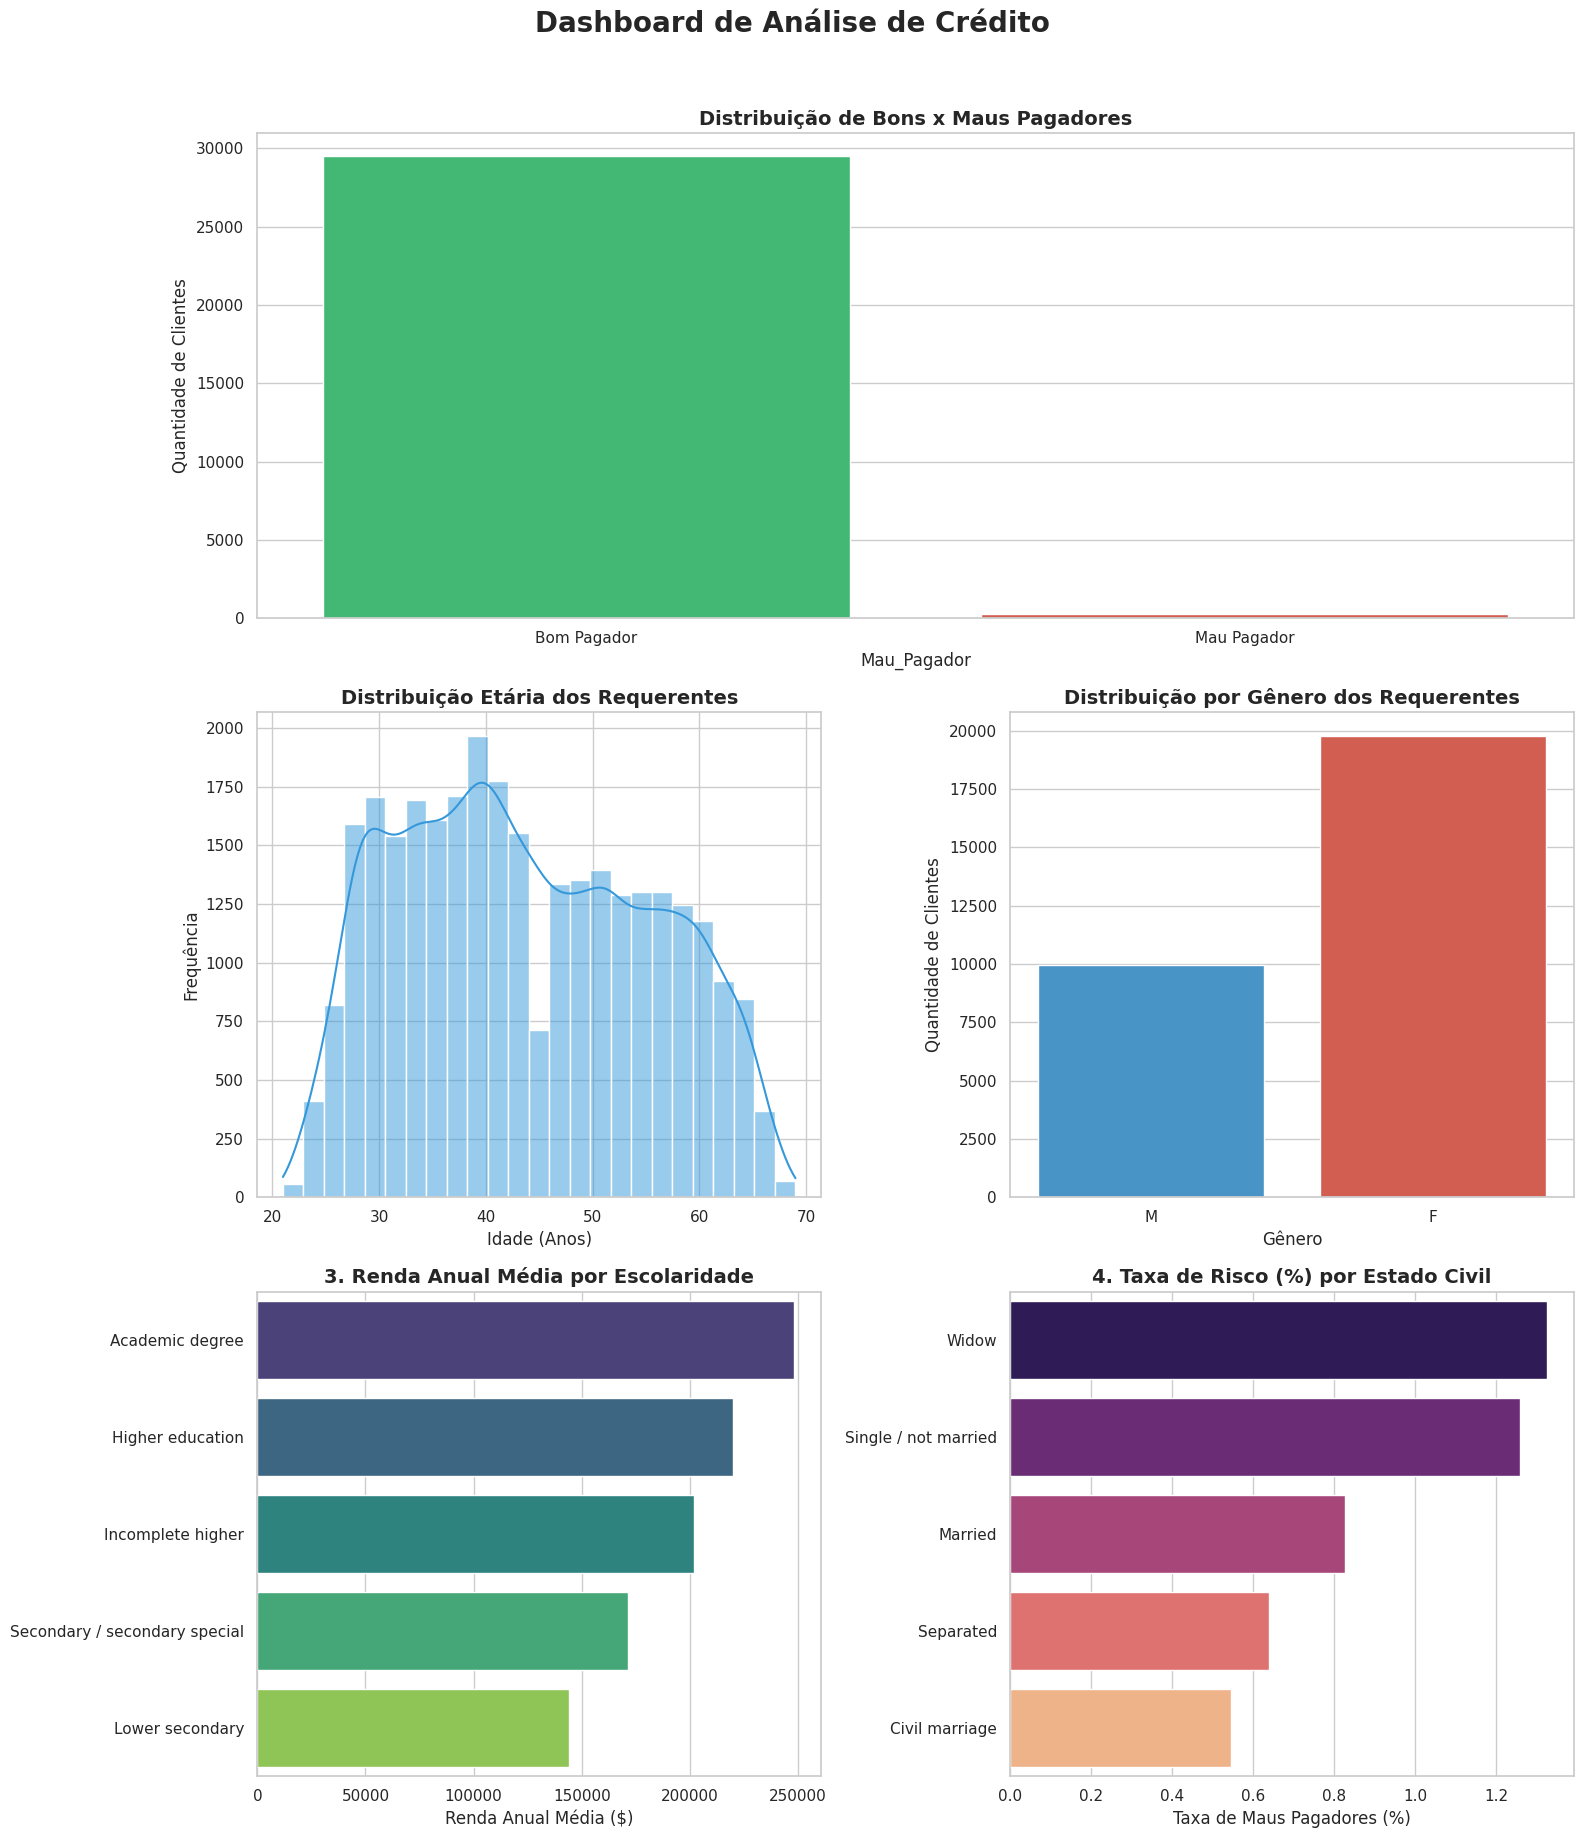

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 18)

fig = plt.figure()
fig.suptitle('Dashboard de Análise de Crédito', fontsize=20, fontweight='bold', y=1.02)

gs = fig.add_gridspec(3, 2)

ax0 = fig.add_subplot(gs[0, :])
sns.countplot(data=df, x='Mau_Pagador', hue='Mau_Pagador', palette=['#2ecc71', '#e74c3c'], ax=ax0, legend=False)
ax0.set_title('Distribuição de Bons x Maus Pagadores', fontweight='bold', fontsize=14)
ax0.set_xticks([0, 1])
ax0.set_xticklabels(['Bom Pagador', 'Mau Pagador'])
ax0.set_ylabel('Quantidade de Clientes')

ax1 = fig.add_subplot(gs[1, 0])
sns.histplot(data=df, x='Idade', kde=True, bins=25, color='#3498db', ax=ax1)
ax1.set_title('Distribuição Etária dos Requerentes', fontweight='bold', fontsize=14)
ax1.set_xlabel('Idade (Anos)')
ax1.set_ylabel('Frequência')

ax2 = fig.add_subplot(gs[1, 1])
sns.countplot(data=df, x='Genero', hue='Genero', palette=['#3498db', '#e74c3c'], ax=ax2, legend=False)
ax2.set_title('Distribuição por Gênero dos Requerentes', fontweight='bold', fontsize=14)
ax2.set_xlabel('Gênero')
ax2.set_ylabel('Quantidade de Clientes')

ax3 = fig.add_subplot(gs[2, 0])
renda_escolaridade = (
    df.groupby('Escolaridade')['Renda_Anual'].mean().sort_values(ascending=False)
)
sns.barplot(x=renda_escolaridade.values, y=renda_escolaridade.index, hue=renda_escolaridade.index, palette='viridis', ax=ax3, legend=False)
ax3.set_title('3. Renda Anual Média por Escolaridade', fontweight='bold', fontsize=14)
ax3.set_xlabel('Renda Anual Média ($)')
ax3.set_ylabel('')

ax4 = fig.add_subplot(gs[2, 1])
taxa_estado_civil = (
    df.groupby('Estado_Civil')['Mau_Pagador'].mean().sort_values(ascending=False) * 100
)
sns.barplot(x=taxa_estado_civil.values, y=taxa_estado_civil.index, hue=taxa_estado_civil.index, palette='magma', ax=ax4, legend=False)
ax4.set_title('4. Taxa de Risco (%) por Estado Civil', fontweight='bold', fontsize=14)
ax4.set_xlabel('Taxa de Maus Pagadores (%)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# **Etapa 3: Preparação dos Dados**

In [ ]:
# Remove a coluna de ID das entradas, já que esta é irrelevante para as previsões
X = df.drop(columns=['ID', 'Mau_Pagador'])
# Define a coluna de mau pagador como saída, já que identificar possíveis maus pagadores é o objetivo dos modelos
y = df['Mau_Pagador'].astype(int)

# Divide os dados entre treino e teste, de forma a evitar que os modelos fiquem viciados nos dados com que aprenderam
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Definindo as colunas categóricas que ainda precisam ser modificadas via TargetEncoder
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# O Target Encoding foi escolhido porque converte categorias em valores numéricos considerando sua relação com a variável alvo Mau_Pagador.
# Essa técnica é útil quando existem muitas categorias, pois evita aumentar muito a quantidade de colunas como aconteceria no One-Hot Encoding.
# Para evitar vazamento de dados, o encoder é treinado apenas com os dados de treino.

# Definindo as colunas que receberão RobustScaler a fim de aumentar a resistência do modelo aos outliers
cols_robust = ['Renda_Anual', 'Idade', 'Anos_Empregado', 'Qtd_Filhos', 'Qtd_Meses_Historico', 'Qtd_Atrasos_Leves', 'Qtd_Atrasos_Graves', 'Qtd_Meses_Pagos', 'Qtd_Meses_Sem_Emprestimo']

# O RobustScaler foi escolhido porque essas variáveis podem conter valores extremos, especialmente renda anual e tempo de emprego.
# Ele utiliza mediana e intervalo interquartil, sendo menos sensível a outliers do que a padronização tradicional.

# Aplica o TargetEncoder e RobustScaler na base de dados com base no tipo dessas colunas
preprocessamento = Pipeline(steps=[
    ('target_encoder', TargetEncoder(cols=cat_cols)),
    ('scaler', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), cols_robust)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])

# **Etapa 4: Classificação**

In [ ]:
# Modelo base
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)

# Pipeline completo
pipeline_rf = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    ('classificador', rf)
])

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Espaço de busca dos hiperparâmetros
param_dist = {
    'classificador__n_estimators': [200, 300, 500, 700],
    'classificador__max_depth': [None, 5, 10, 15, 20, 30],
    'classificador__min_samples_split': [2, 5, 10, 20],
    'classificador__min_samples_leaf': [1, 2, 4, 8],
    'classificador__max_features': ['sqrt', 'log2']
}

# Métricas de avaliação
scoring = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'balanced_accuracy': 'balanced_accuracy'
}

# Busca dos melhores hiperparâmetros a partir do RandomizedSearchCV, que otimiza os hiperparâmetros do modelo e do pré-processamento de forma integrada e segura
busca_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=10,
    refit='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_rf.fit(X_train, y_train)
modelo_rf = busca_rf.best_estimator_

print(f"\nMelhores hiperparâmetros encontrados: \n{busca_rf.best_params_}\n")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Melhores hiperparâmetros encontrados: 
{'classificador__n_estimators': 300, 'classificador__min_samples_split': 10, 'classificador__min_samples_leaf': 2, 'classificador__max_features': 'log2', 'classificador__max_depth': 15}

Melhor Average Precision na validação: 
0.991884763087954



Acurácia: 0.9900
Acurácia balanceada: 0.6392
Precisão: 0.4000
Recall: 0.2821
F1-score: 0.3308
ROC-AUC: 0.7840
Precisão média: 0.2504



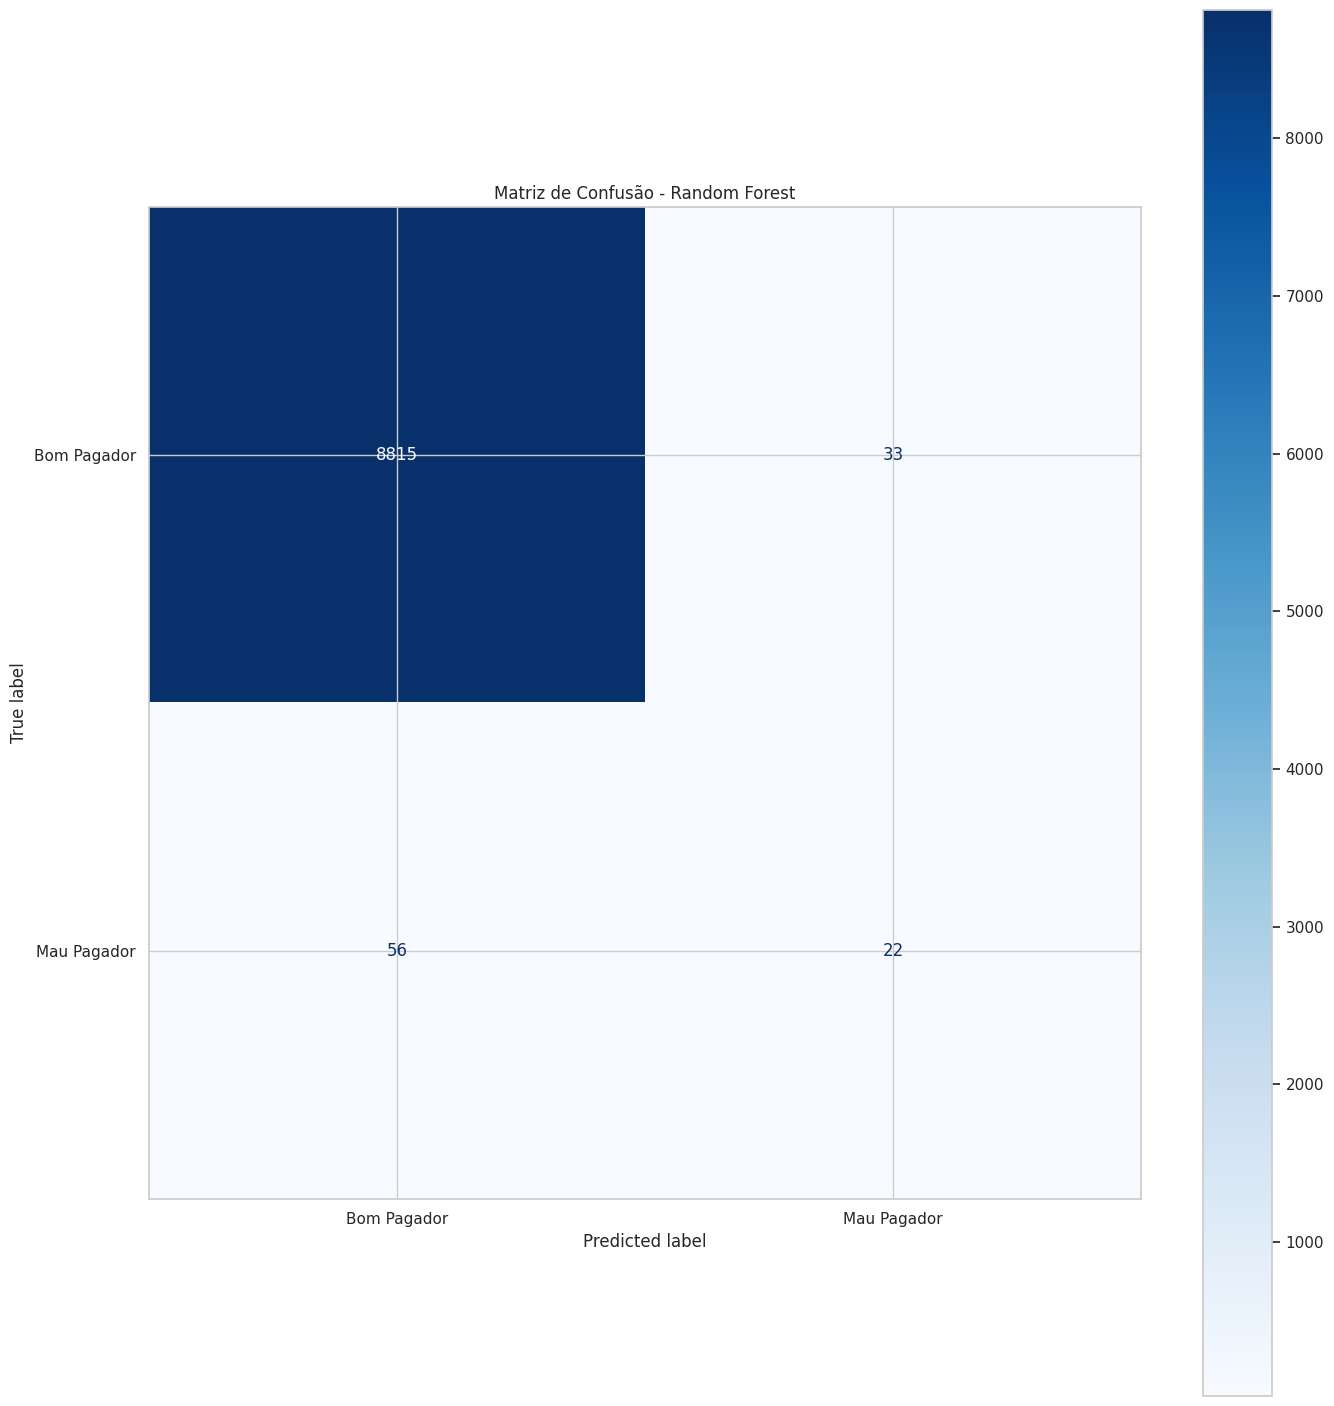

In [ ]:
# Avaliando a probabilidade da classe positiva (Mau_Pagador = 1)
y_proba = modelo_rf.predict_proba(X_test)[:, 1]

# Fazendo a predição padrão com limiar 0.5
y_pred = (y_proba >= 0.5).astype(int)

# Exibe os resultados obtidos pelo modelo treinado
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Acurácia balanceada: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Precisão média: {average_precision_score(y_test, y_proba):.4f}\n")

# Exibe a matriz de confusão do modelo a fim de identificar seu desempenho
matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Bom Pagador', 'Mau Pagador']
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [ ]:
# Ajustando os limiares de decisão do modelo
limiares = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

resultados_limiares = []

for limiar in limiares:
    y_pred_limiar = (y_proba >= limiar).astype(int)

    resultados_limiares.append({
        'Limiar': limiar,
        'Precisao': precision_score(y_test, y_pred_limiar, zero_division=0),
        'Recall': recall_score(y_test, y_pred_limiar, zero_division=0),
        'F1-score': f1_score(y_test, y_pred_limiar, zero_division=0),
        'Acuracia_Balanceada': balanced_accuracy_score(y_test, y_pred_limiar)
    })

df_limiares = pd.DataFrame(resultados_limiares)
display(df_limiares)

,Limiar,Precisao,Recall,F1-score,Acuracia_Balanceada
0,0.05,0.014412,0.897436,0.028369,0.678205
1,0.10,0.017380,0.692308,0.033909,0.673629
2,0.15,0.023073,0.525641,0.044205,0.664719
3,0.20,0.040276,0.448718,0.073918,0.677230
4,0.25,0.069712,0.371795,0.117409,0.664028
5,0.30,0.135417,0.333333,0.192593,0.657286
6,0.40,0.296296,0.307692,0.301887,0.650625
7,0.50,0.400000,0.282051,0.330827,0.639161


In [ ]:
print("Iniciando o cálculo dos valores SHAP (isso pode levar alguns segundos)...")

# 1. Extraímos as peças do nosso Pipeline treinado
preprocessor = modelo_rf.named_steps['preprocessamento']
rf_model = modelo_rf.named_steps['classificador']

# 2. O SHAP precisa dos dados JÁ PROCESSADOS (escalados e encodados)
X_test_processed = preprocessor.transform(X_test)

# Como o output do transform pode ser um array numpy, vamos garantir que
# os nomes das colunas originais sejam mantidos para o gráfico ficar legível
feature_names = X_train.columns.tolist()

# 3. Cria o explicador baseado em Árvores (TreeExplainer)
explainer = shap.TreeExplainer(rf_model)

# 4. Calcula os valores SHAP para os dados de teste
# Nota: Se o dataset for gigantesco, usamos um shap.sample(X_test_processed, 500) para não travar a máquina.
shap_values = explainer.shap_values(X_test_processed)

# Para Random Forest (classificação binária), o SHAP geralmente retorna uma lista com 2 arrays:
# [Valores SHAP da Classe 0, Valores SHAP da Classe 1].
# Queremos analisar o que leva o modelo a classificar alguém como Mau Pagador (Classe 1).
if isinstance(shap_values, list):
    valores_mau_pagador = shap_values[1]
elif len(shap_values.shape) == 3: # Compatibilidade com versões mais novas do SHAP
    valores_mau_pagador = shap_values[:, :, 1]
else:
    valores_mau_pagador = shap_values

# 5. Plota o Gráfico Resumo (Summary Plot)
plt.figure(figsize=(10, 8))
plt.title("O que faz um cliente ser classificado como Mau Pagador? (SHAP Values)", fontsize=14, fontweight='bold', pad=20)

shap.summary_plot(
    valores_mau_pagador,
    X_test_processed,
    feature_names=feature_names,
    show=False # show=False permite que o matplotlib adicione o título acima
)

plt.tight_layout()
plt.show()

# **Etapa 5: Regressão**

# **Etapa 6: Análise Não Supervisionada**

# **Etapa Final: Salvamento dos Modelos**

In [ ]:
# Definindo o nome dos arquivos dos modelos
nome_classificacao = 'classificacao.pkl'
nome_regressao = 'regressao.pkl'
nome_nao_supervisionado = 'nao_supervisionado.pkl'

# Salva os pipelines completos dos modelos, algo fundamental para a utilização futura destes, já que quando forem utilizados, os dados virão sem RobustScaler e sem TargetEncoder
joblib.dump(modelo_rf, nome_classificacao)

✅ SUCESSO: Modelo salvo fisicamente como 'sistema_risco_credito_rf.pkl'!

No seu Back-End (API FastAPI, Flask, etc.), você só precisará de 3 linhas de código para usá-lo:

import joblib
import pandas as pd
modelo_producao = joblib.load('sistema_risco_credito_rf.pkl')
risco_previsto = modelo_producao.predict(dados_do_novo_cliente_em_dataframe)
